In [1]:
import geometric_predict
import cnn_predict
import cv2
from matplotlib import pyplot as plt
import numpy as np
import torch

In [5]:
INTERNAL_CROP_RECT = (900, 540, 380, 240) # User confirmed crop bounds

alum_img_path = "./images/test_images/aluminum_1.jpg"
glass_img_path = "./images/test_images/success_7.jpg"

img_alum = cv2.imread(alum_img_path)
img_glass = cv2.imread(glass_img_path)

Deterministic decision:  True


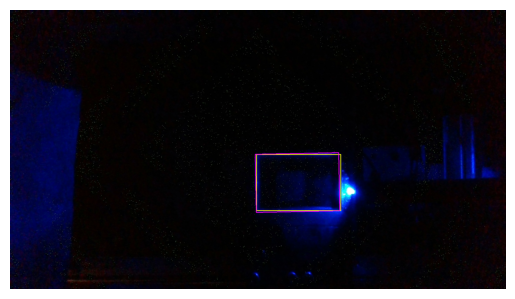

In [6]:
alum_bound, glass_bound, deterministic_decision = geometric_predict.predict_single_static(img_alum, img_glass, INTERNAL_CROP_RECT, 90., 3.)
print("Deterministic decision: ", deterministic_decision)

alum_bound = alum_bound[0]
glass_bound = glass_bound[0]
# draw aluminum rectangle
cv2.rectangle(img_glass,
              (INTERNAL_CROP_RECT[0] + alum_bound[0][0], INTERNAL_CROP_RECT[1] + alum_bound[0][1]),
              (INTERNAL_CROP_RECT[0] + alum_bound[2][0], INTERNAL_CROP_RECT[1] + alum_bound[2][1]),
              (0, 255, 255), 2)

# draw glass rectangle
box = glass_bound.reshape((-1, 1, 2)).astype(np.int32)
off_x = INTERNAL_CROP_RECT[0]
off_y = INTERNAL_CROP_RECT[1]

box_offset = box + [off_x, off_y]
cv2.drawContours(img_glass, [box_offset], 0, (255, 0,255), 2)

# Show the frame
img_rgb = cv2.cvtColor(img_glass, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

Model loaded successfully.
Predictive decision:  Success (0.73)


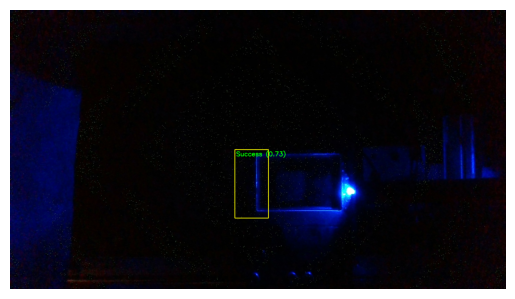

In [7]:
img_glass = cv2.imread(glass_img_path)
# load model
model_path = "./cnn_checkpoints/cnn_best_model_epoch_50_acc_100.00.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bot_model = cnn_predict.load_model(model_path, device)

predictive_decision, text_color = cnn_predict.predict_single_static(img_glass, bot_model, device)
print("Predictive decision: ", predictive_decision)

ROI_X = 870
ROI_Y = 260
ROI_WIDTH = 130
ROI_HEIGHT = 265
ROI_OFFSET = 280

cv2.rectangle(img_glass, (ROI_X, ROI_Y + ROI_OFFSET), (ROI_X + ROI_WIDTH, ROI_Y + ROI_OFFSET + ROI_HEIGHT), (0, 255, 255), 2) # Yellow ROI box
cv2.putText(img_glass, predictive_decision, (ROI_X + 5, ROI_Y + ROI_OFFSET + 25), # Position near top-left of ROI
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, text_color, 2)

# Show the frame
img_rgb = cv2.cvtColor(img_glass, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off') 
plt.show()